# Análise Exploratória de Dados (EDA) — Indicadores SPI (2023)

**Objetivo**: Realizar uma exploração estatística do Índice de Desempenho Estatístico (SPI) global, focando no desempenho de países e regiões no ano de 2023.

Este notebook documenta o fluxo de trabalho para:
1. **Preparação**: Carregamento e filtragem temporal do dataset.
2. **Rankings**: Identificação das nações com melhores e piores ecossistemas de dados.
3. **Análise Regional**: Comparação de médias por blocos geográficos.
4. **Visualização**: Distribuição estatística (Boxplots) e relação entre porte populacional e qualidade de dados (Scatter plots).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Etapa 0 - Verificação de Nulos e Base

In [4]:
spi_base = pd.read_csv('spi_indicators.csv')

In [5]:
spi_base.describe(include="all")

,iso3c,country,region,income,year,population,overall_score,data_use_score,data_services_score,data_products_score,data_sources_score,data_infrastructure_score
count,4340,4340,4340,4340,4340.000000,4.340000e+03,1425.000000,4340.000000,1436.000000,4085.000000,1560.000000,1519.000000
unique,217,217,7,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,DNK,Denmark,Europe & Central Asia,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,20,20,1160,1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2013.500000,3.338109e+07,64.947420,50.745714,64.781546,55.212702,51.891090,54.944042
std,NaN,NaN,NaN,NaN,5.766946,1.321476e+08,17.511148,29.468643,23.474755,18.684428,20.057036,28.223303
min,NaN,NaN,NaN,NaN,2004.000000,9.791000e+03,11.769583,0.000000,0.333333,4.893750,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,2008.750000,7.441640e+05,52.835833,30.000000,56.183333,45.506250,36.881250,30.000000
50%,NaN,NaN,NaN,NaN,2013.500000,5.940858e+06,64.282500,40.000000,64.000000,58.025000,52.816667,50.000000
75%,NaN,NaN,NaN,NaN,2018.250000,2.167538e+07,80.197083,80.000000,86.466667,68.431250,68.629167,80.000000


In [6]:
spi_base.isnull().sum()

iso3c                           0
country                         0
region                          0
income                          0
year                            0
population                      0
overall_score                2915
data_use_score                  0
data_services_score          2904
data_products_score           255
data_sources_score           2780
data_infrastructure_score    2821
dtype: int64

## Etapa 1 — Preparação e Filtragem
Nesta etapa, o dataset base é carregado. Para garantir uma análise atualizada e evitar distorções temporais, filtramos os registros para manter apenas o ano de **2023**.

In [7]:
spi = spi_base[spi_base['year']==2023].copy()
spi.head()

,iso3c,country,region,income,year,population,overall_score,data_use_score,data_services_score,data_products_score,data_sources_score,data_infrastructure_score
0,DNK,Denmark,Europe & Central Asia,High income,2023,5946952,95.255833,100.0,98.466667,90.71250,87.100,100.0
1,FIN,Finland,Europe & Central Asia,High income,2023,5584264,95.115417,100.0,96.433333,90.96875,88.175,100.0
2,POL,Poland,Europe & Central Asia,High income,2023,36685849,94.653750,100.0,97.300000,84.54375,91.425,100.0
3,SWE,Sweden,Europe & Central Asia,High income,2023,10536632,94.410000,100.0,96.000000,90.57500,85.475,100.0
4,ESP,Spain,Europe & Central Asia,High income,2023,48373336,94.325000,100.0,91.200000,92.62500,87.800,100.0


In [23]:
spi.columns

Index(['iso3c', 'country', 'region', 'income', 'year', 'population',
       'overall_score', 'data_use_score', 'data_services_score',
       'data_products_score', 'data_sources_score',
       'data_infrastructure_score'],
      dtype='str')

## Etapa 2 — Rankings de Desempenho (Top & Bottom)
Nesta seção, identificamos os extremos da distribuição do SPI. O objetivo é listar os 10 países que lideram a maturidade estatística global e os 10 que enfrentam os maiores desafios de infraestrutura e serviços de dados.

In [25]:
# Quais são os 10 países com melhor desempenho no SPI?
top_10 = spi.nlargest(10, 'overall_score')[['country', 'overall_score', 'region']]
print("Top 10 Países (SPI):\n", top_10)

Top 10 Países (SPI):
        country  overall_score                 region
0      Denmark      95.255833  Europe & Central Asia
1      Finland      95.115417  Europe & Central Asia
2       Poland      94.653750  Europe & Central Asia
3       Sweden      94.410000  Europe & Central Asia
4        Spain      94.325000  Europe & Central Asia
5  Netherlands      94.322500  Europe & Central Asia
6     Slovenia      94.220417  Europe & Central Asia
7     Portugal      93.778333  Europe & Central Asia
8        Italy      93.638750  Europe & Central Asia
9       Norway      93.556667  Europe & Central Asia


In [33]:
# Quais são os 10 países com pior desempenho no SPI?
bottom_10 = spi.nsmallest(10, 'overall_score')[['country', 'overall_score', 'region']]
print("Bottom 10 Países (SPI):\n", bottom_10)

Bottom 10 Países (SPI):
                    country  overall_score                      region
186            South Sudan      27.511250          Sub-Saharan Africa
185           Turkmenistan      30.717500       Europe & Central Asia
184                  Libya      33.064167  Middle East & North Africa
183      Equatorial Guinea      35.061250          Sub-Saharan Africa
182            Yemen, Rep.      35.694583  Middle East & North Africa
181   Syrian Arab Republic      36.177917  Middle East & North Africa
180  Micronesia, Fed. Sts.      36.507917         East Asia & Pacific
179          Venezuela, RB      39.392500   Latin America & Caribbean
178                  Haiti      39.605417   Latin America & Caribbean
177       Marshall Islands      40.981667         East Asia & Pacific


## Etapa 3 — Análise Agregada por Região
Para entender o cenário geopolítico da qualidade dos dados, agrupamos os países por região. Esta métrica ajuda a identificar se a maturidade dos sistemas estatísticos está concentrada em blocos geográficos específicos.

In [26]:
# Quais são as melhores regiões (SPI)?
top_regioes = spi.groupby('region')['overall_score'].mean()
print("Melhores Regiões (SPI):\n", top_regioes)

Melhores Regiões (SPI):
 region
East Asia & Pacific           65.824339
Europe & Central Asia         84.914082
Latin America & Caribbean     66.060768
Middle East & North Africa    64.245179
North America                 93.446042
South Asia                    67.835365
Sub-Saharan Africa            60.376694
Name: overall_score, dtype: float64


## Etapa 4 — Visualizações Estatísticas e Correlação
Utilizamos gráficos para aprofundar a compreensão da variabilidade dos dados:
- **Boxplot**: Visualiza a dispersão do score SPI e identifica a presença de *outliers* dentro de cada região geográfica.
- **Scatter Plot (Escala Log)**: Explora a hipótese de que o tamanho da população influencia a infraestrutura de dados de um país.

C:\Users\Dell\AppData\Local\Temp\ipykernel_6832\2255710901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spi, x='region', y='overall_score', palette='viridis')


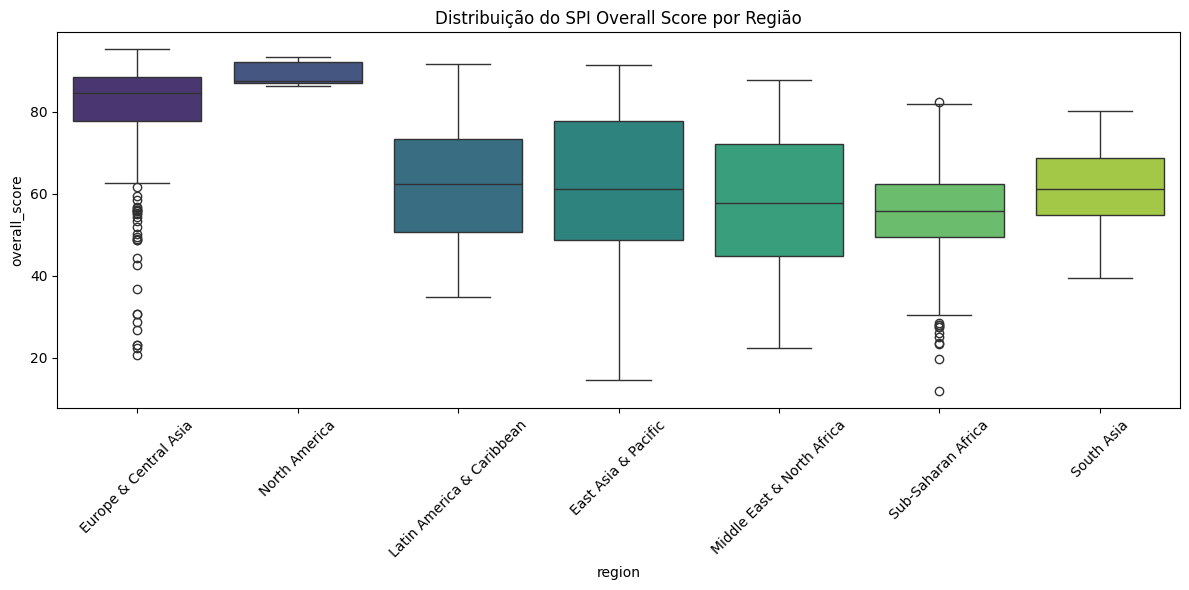

In [7]:
# 1.2. Distribuição do Score por Região
plt.figure(figsize=(12, 6))
sns.boxplot(data=spi, x='region', y='overall_score', palette='viridis')
plt.title('Distribuição do SPI Overall Score por Região')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('distribuicao_regiao.png')

In [28]:
# Os melhores países no overall_score são os mesmos que os países no data_sources_score?
top_10_data_sources = spi.nlargest(10, 'data_sources_score')[['country', 'region', 'data_sources_score', 'overall_score']]
top_10_data_sources

,country,region,data_sources_score,overall_score
33,Singapore,East Asia & Pacific,94.175,88.767500
2,Poland,Europe & Central Asia,91.425,94.653750
10,Canada,North America,89.825,93.461667
1,Finland,Europe & Central Asia,88.175,95.115417
4,Spain,Europe & Central Asia,87.800,94.325000
0,Denmark,Europe & Central Asia,87.100,95.255833
17,Mexico,Latin America & Caribbean,86.900,91.638333
15,Germany,Europe & Central Asia,86.675,92.470833
22,Czechia,Europe & Central Asia,86.075,91.041250
11,United States,North America,85.625,93.430417


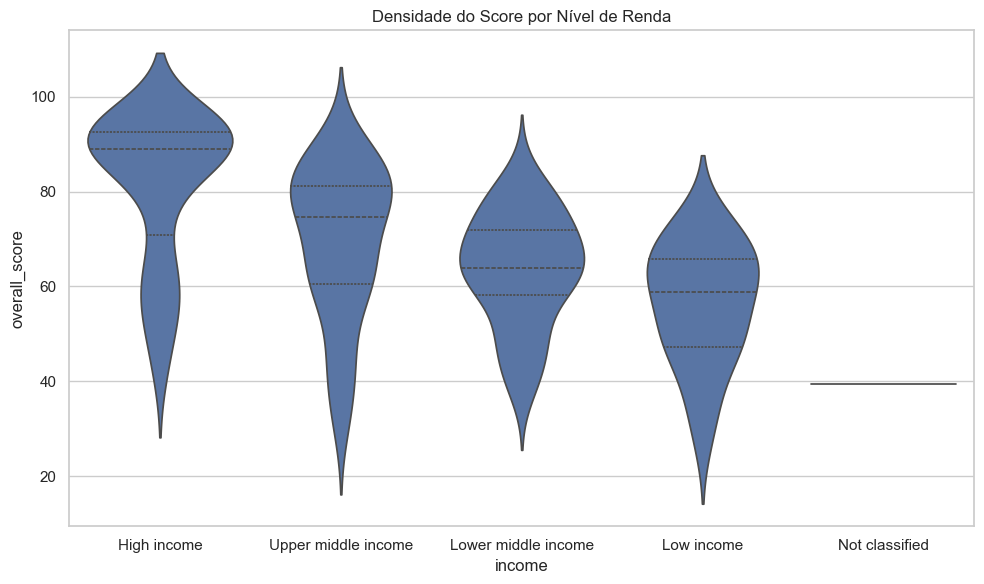

In [29]:
# Como é a distribuição do Score por Nível de Renda?
plt.figure(figsize=(10, 6))
sns.violinplot(data=spi, x='income', y='overall_score', inner="quart")
plt.title('Densidade do Score por Nível de Renda')
plt.tight_layout()
plt.savefig('densidade_renda.png')

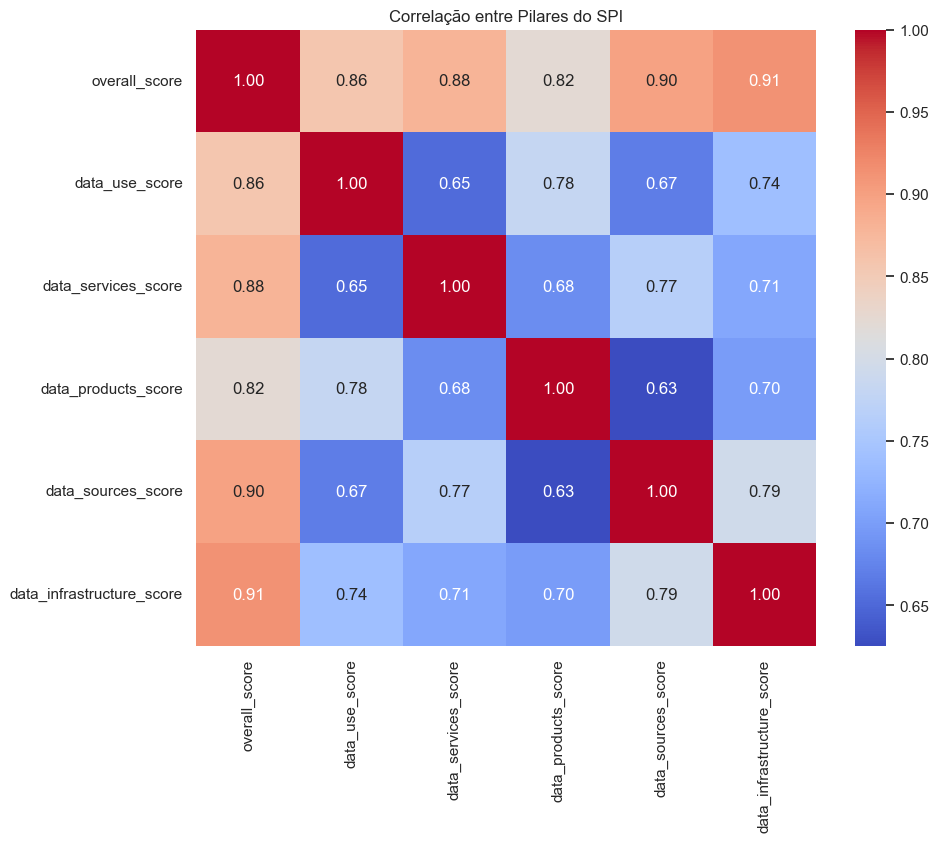

In [32]:
# Qual a correlação entre os Pilares do SPI?
pilares = [
    'data_use_score', 'data_services_score', 'data_products_score', 
    'data_sources_score', 'data_infrastructure_score'
]

# 2.1. Heatmap de Correlação
plt.figure(figsize=(10, 8))
corr = spi[['overall_score'] + pilares].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Pilares do SPI')
plt.savefig('heatmap_correlacao.png')

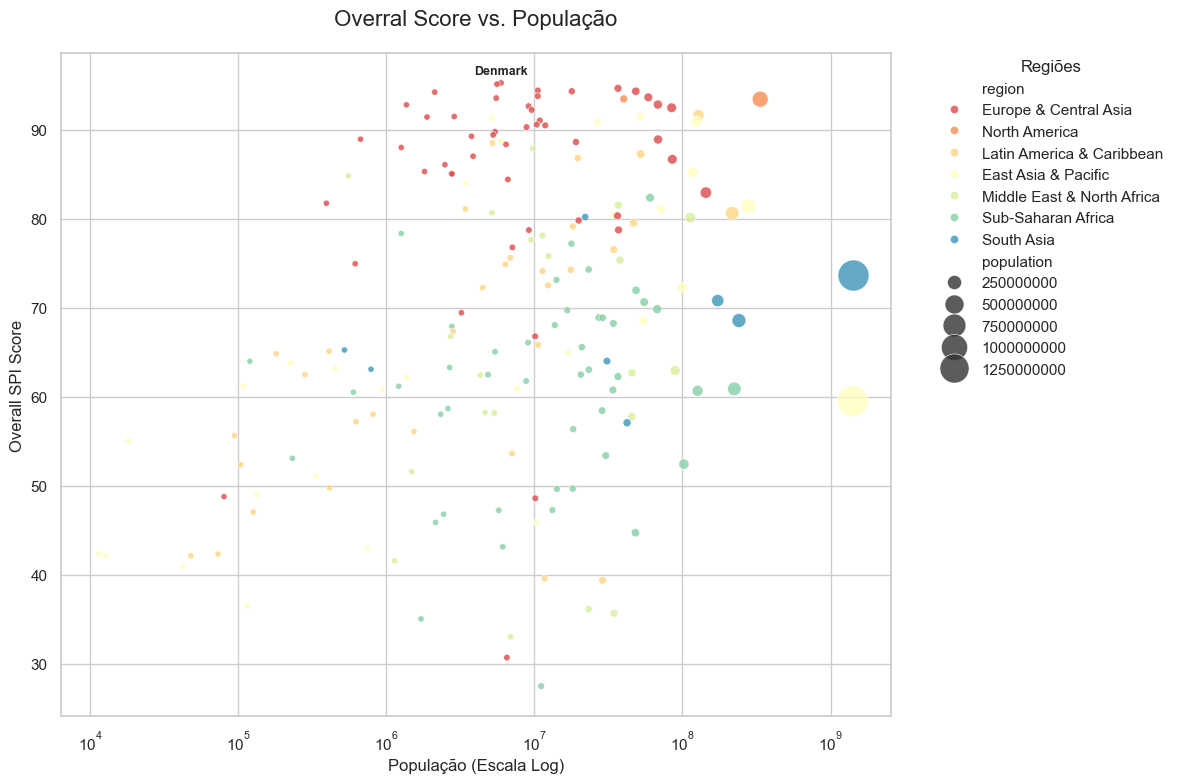

In [31]:

# Configuração de estilo para um look mais "clean"
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Ajuste de transparência (alpha) para lidar com o overlap
# 2. Tamanho fixo ou mapeado para algo que NÃO seja o eixo Y (ex: pop ou constante)
scatter = sns.scatterplot(
    data=spi, 
    x='population', 
    y='overall_score', 
    hue='region', 
    size='population', # Opcional: usar pop para tamanho faz mais sentido visualmente
    sizes=(20, 500),   # Range de tamanho das bolhas
    alpha=0.8,         # Transparência é vital aqui
    palette='Spectral', 
    edgecolor='w',     # Borda branca ajuda a separar as bolhas
    linewidth=0.5
)

# Ajuste do Eixo X para Log
plt.xscale('log')

# Títulos e Labels mais limpos
plt.title('Overral Score vs. População', fontsize=16, pad=20)
plt.xlabel('População (Escala Log)', fontsize=12)
plt.ylabel('Overall SPI Score', fontsize=12)

# Colocamos a legenda fora do gráfico para não tampar os dados
plt.legend(
    title='Regiões', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0.,
    frameon=False
)

# Opcional: Anotar países específicos (Outliers ou Top 1)
# Aqui pegamos o país com maior score para dar contexto
top_country = spi.loc[spi['overall_score'].idxmax()]
plt.text(
    top_country['population'], 
    top_country['overall_score'] + 1, 
    top_country['country'], 
    fontsize=9, weight='bold', ha='center'
)

plt.tight_layout()
plt.show()

## Conclusão: Análise Regional do SPI (2023)

A análise dos dados revela um cenário de alta desigualdade na capacidade estatística global:

### 1. Desempenho Regional
* **Líderes**: **América do Norte (93,45)** e **Europa & Ásia Central (84,91)** possuem os ecossistemas de dados mais maduros.
* **Intermediários**: **Sul da Ásia (67,84)** e **América Latina & Caribe (66,06)** apresentam desempenho moderado.
* **Retaguarda**: A **África Subsaariana (60,38)** apresenta o maior gap de desenvolvimento do índice.

### 2. Extremos Observados
* **Máxima**: **Dinamarca (95,26)** define o padrão global de excelência em sistemas de dados.
* **Mínima**: **Sudão do Sul (27,51)** enfrenta as maiores barreiras estruturais para produção estatística.

### Resumo
O desempenho estatístico é fortemente influenciado pelo contexto regional. A disparidade de quase **70 pontos** entre os extremos ressalta que a capacidade de gerar evidências para políticas públicas ainda é um recurso distribuído de forma desigual globalmente.